
# Convergence of Sequences: An Engineering Dataset Exploration

**Goal.** You will work with synthetic (but realistic) engineering time series
that converge to a known limit $L$. Your job is to find, for a given
$\varepsilon > 0$, the smallest index $N$ such that

$$ |a_n - L| < \varepsilon \quad \text{for all } n \ge N. $$

This is exactly the formal $\varepsilon$–$N$ definition of convergence:

$$ \lim_{n\to\infty} a_n = L \iff \forall \varepsilon>0,\ \exists N \in \mathbb{N} \text{ s.t. } n\ge N \implies |a_n-L|<\varepsilon. $$

Two datasets are provided:

1. **RC circuit charging voltage** — monotonic approach to the limit. Good warm-up.
2. **Damped spring–mass–damper step response** — oscillates around the limit before
   settling. This is the more interesting case: you cannot just find where the
   sequence first gets close, because it might swing back out of the band later.
   (This is literally what "settling time" means in a controls course — you're
   about to derive that concept from first principles.)

A noisy version is included at the end, with a discussion question about what
happens to the $\varepsilon$–$N$ definition when there's measurement noise.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)



## Dataset 1: RC Circuit Charging Voltage

A capacitor charging through a resistor toward supply voltage $V_0$ follows

$$ V(t) = V_0\left(1 - e^{-t/(RC)}\right). $$

As $t \to \infty$, $V(t) \to V_0$. We'll sample this at discrete times to get a
sequence $a_n = V(t_n)$, and treat $L = V_0$ as the known limit.


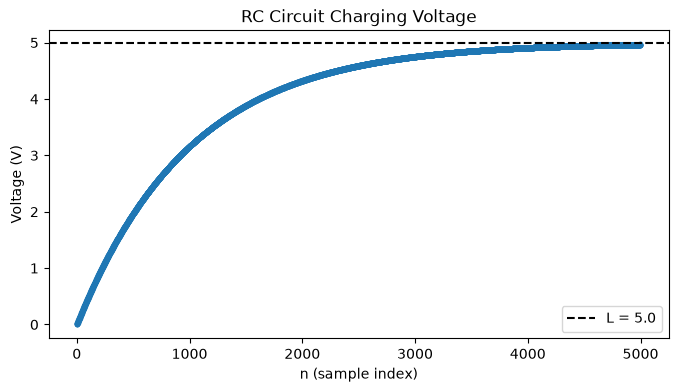

In [5]:
# --- Circuit parameters ---
V0 = 5.0        # supply voltage (limit L)
R = 1000.0      # ohms
C = 0.001       # farads
tau = R * C     # time constant

n = np.arange(0, 5000)      # sample index
dt = 0.001                 # seconds per sample
t = n * dt

a_n = V0 * (1 - np.exp(-t / tau))   # the sequence a_n = V(t_n)
L = V0

plt.figure(figsize=(8, 4))
plt.plot(n, a_n, marker='.')
plt.axhline(L, color='k', linestyle='--', label=f'L = {L}')
plt.xlabel('n (sample index)')
plt.ylabel('Voltage (V)')
plt.title('RC Circuit Charging Voltage')
plt.legend()
plt.show()



### Task 1

Pick an $\varepsilon$ (try something small, like $\varepsilon = 0.05$).
Write a function `find_N(sequence, L, epsilon)` that returns the smallest $N$
such that **every** later term satisfies $|a_n - L| < \varepsilon$ (not just the
first term that happens to land close — check that it *stays* close).

Then verify your answer by plotting the $\varepsilon$-band $(L-\varepsilon, L+\varepsilon)$
on top of the sequence and confirming visually that $a_n$ enters the band at $n=N$
and never leaves.


In [6]:
def find_N(sequence, L, epsilon):
    """
    Return the smallest N such that |sequence[n] - L| < epsilon for all n >= N.
    Returns None if no such N exists within the given data.
    """
    # TODO: implement this
    # Hint: work backwards from the end of the array, or check suffixes.
    pass

# Example usage once implemented:
# epsilon = 0.05
# N = find_N(a_n, L, epsilon)
# print(f"N = {N}")



## Dataset 2: Damped Spring–Mass–Damper Step Response

A second-order underdamped system responding to a step input follows

$$ x(t) = x_{ss}\left(1 - e^{-\zeta \omega_n t}\left(\cos(\omega_d t) + \frac{\zeta}{\sqrt{1-\zeta^2}}\sin(\omega_d t)\right)\right) $$

where $\omega_d = \omega_n\sqrt{1-\zeta^2}$. Unlike the RC circuit, this **overshoots**
and oscillates around $x_{ss}$ before settling — so finding $N$ requires you to look
past the first time it gets close, since it may swing back out.


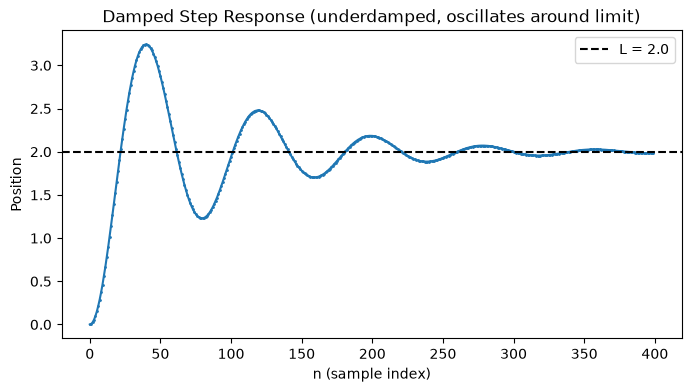

In [7]:
# --- System parameters ---
x_ss = 2.0       # steady-state value (limit L)
zeta = 0.15      # damping ratio (small = more oscillation, harder problem)
wn = 8.0         # natural frequency (rad/s)
wd = wn * np.sqrt(1 - zeta**2)

n2 = np.arange(0, 400)
dt2 = 0.01
t2 = n2 * dt2

b_n = x_ss * (1 - np.exp(-zeta * wn * t2) *
              (np.cos(wd * t2) + (zeta / np.sqrt(1 - zeta**2)) * np.sin(wd * t2)))
L2 = x_ss

plt.figure(figsize=(8, 4))
plt.plot(n2, b_n, marker='.', markersize=2)
plt.axhline(L2, color='k', linestyle='--', label=f'L = {L2}')
plt.xlabel('n (sample index)')
plt.ylabel('Position')
plt.title('Damped Step Response (underdamped, oscillates around limit)')
plt.legend()
plt.show()



### Task 2

Try $\varepsilon = 0.1$ and $\varepsilon = 0.02$ on `b_n`. Use your `find_N`
function from Task 1 (it should work unchanged on this sequence).

Discuss: why does $N$ grow so much faster here than in Dataset 1 as $\varepsilon$
shrinks? What role does the damping ratio `zeta` play? Try re-running the cell
above with `zeta = 0.05` and `zeta = 0.5` and see how $N$ changes for a fixed
$\varepsilon$.

**Connection to your controls course:** the smallest such $N$ (converted to time,
$N \cdot dt$) is exactly what's called the **settling time** of a system — usually
defined with $\varepsilon$ as 2% or 5% of the step size. You've just derived that
concept from the $\varepsilon$–$N$ definition of a limit.


In [8]:
# Your exploration here




## Dataset 3 (Optional / Discussion): Adding Measurement Noise

Real sensors are noisy. Let's add Gaussian noise to Dataset 1 and see what
happens to the $\varepsilon$–$N$ search.


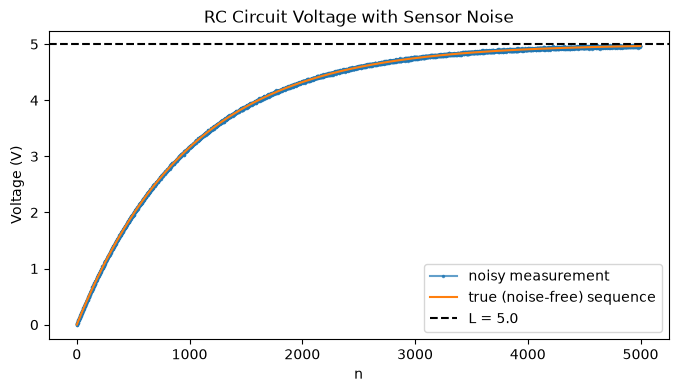

In [9]:
noise_std = 0.01
a_n_noisy = a_n + rng.normal(0, noise_std, size=a_n.shape)

plt.figure(figsize=(8, 4))
plt.plot(n, a_n_noisy, marker='.', markersize=3, alpha=0.7, label='noisy measurement')
plt.plot(n, a_n, color='C1', label='true (noise-free) sequence')
plt.axhline(L, color='k', linestyle='--', label=f'L = {L}')
plt.xlabel('n')
plt.ylabel('Voltage (V)')
plt.legend()
plt.title('RC Circuit Voltage with Sensor Noise')
plt.show()



### Discussion Question

Try `find_N(a_n_noisy, L, epsilon)` for a small $\varepsilon$ (say, one close to
or smaller than `noise_std`). What happens?

- Does an $N$ even exist for every $\varepsilon > 0$ in the noisy data?
- What does this tell you about the difference between a mathematical sequence
  that provably converges, and a *measurement* of a physical process that is
  approaching a steady state?
- In practice, engineers often report a settling time with a specific,
  not-too-small $\varepsilon$ (e.g. 2%) precisely because of this issue. Why
  does that make sense in light of the $\varepsilon$–$N$ definition?
